In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from astropy.time import Time, TimeDelta
import datetime
plt.style.use('default')
plt.style.use(['science', 'notebook'])
import glob
import os
import re
import pytz
import pandas as pd
from astropy.stats import sigma_clip
from scipy.interpolate import griddata
import cupy as cp

In [2]:
from main import generate_point_source_visibilities, generate_antenna_mapping, inject_point_source, calculate_uvw, calculate_baselines, generate_visibilities

In [3]:
def generate_dirty_map_gpu_chunked(vis, uvw_lambda, res=256, chunk_size=2000):
    """
    GPU DFT imaging with pixel chunking to prevent OutOfMemoryErrors.
    """
    # 1. Setup grid on GPU
    l_axis = cp.linspace(-1, 1, res)
    L, M = cp.meshgrid(l_axis, l_axis)
    dist_sq = L**2 + M**2
    horizon_mask = dist_sq <= 1.0
    
    l_flat = L[horizon_mask].astype(cp.float32)
    m_flat = M[horizon_mask].astype(cp.float32)
    n_flat = cp.sqrt(1.0 - dist_sq[horizon_mask]).astype(cp.float32)
    
    # 2. Transfer data to GPU (Using float32/complex64)
    v_gpu = cp.asarray(vis, dtype=cp.complex64)
    uvw_gpu = cp.asarray(uvw_lambda, dtype=cp.float32)
    
    n_pixels = len(l_flat)
    n_baselines = v_gpu.shape[0]
    n_freqs = v_gpu.shape[1]
    
    # Final result array on GPU
    sky_brightness = cp.zeros(n_pixels, dtype=cp.complex64)
    
    # 3. Process in pixel chunks
    for i in range(0, n_pixels, chunk_size):
        end = min(i + chunk_size, n_pixels)
        l_chunk = l_flat[i:end]
        m_chunk = m_flat[i:end]
        n_chunk = n_flat[i:end]
        
        chunk_sum = cp.zeros(end - i, dtype=cp.complex64)
        
        # Loop over frequencies for this chunk of pixels
        for f_idx in range(n_freqs):
            u = uvw_gpu[:, f_idx, 0]
            v = uvw_gpu[:, f_idx, 1]
            w = uvw_gpu[:, f_idx, 2]
            v_chan = v_gpu[:, f_idx]
            
            # Phase calculation for the chunk: (chunk_size, n_baselines)
            # Using exp(j * theta) = cos(theta) + j*sin(theta) can sometimes be faster,
            # but cp.exp is generally well-optimized.
            phase_arg = 2.0 * cp.pi * (
                cp.outer(l_chunk, u) + 
                cp.outer(m_chunk, v) + 
                cp.outer(n_chunk - 1.0, w)
            )
            
            # Dot product: (chunk_size, baselines) @ (baselines,) -> (chunk_size,)
            chunk_sum += cp.dot(cp.exp(1j * phase_arg.astype(cp.float32)), v_chan)
            
        sky_brightness[i:end] = chunk_sum
        
        # Clear the cache occasionally if VRAM is tight
        cp.get_default_memory_pool().free_all_blocks()

    # 4. Final Reconstruction
    dirty_map = cp.zeros((res, res), dtype=cp.float32)
    dirty_map[horizon_mask] = cp.real(sky_brightness) / (n_baselines * n_freqs)
    
    return cp.asnumpy(dirty_map)

In [4]:
FREQ_MIN = 390.625  # MHz
FREQ_MAX = FREQ_MIN + 93.75  # MHz (375 + 93 MHz bandwidth)
frequencies = np.linspace(FREQ_MIN, FREQ_MAX, 100)
antenna_mapping = generate_antenna_mapping('casm-60.csv')
time_obs = Time.now() 

In [5]:
vis = generate_point_source_visibilities(
    70,
    0,
    10,
    frequencies,
    antenna_mapping,
    time_obs=time_obs,
    integration_time_s=1.0,
    Trec_k=50,
    a_eff_m2=0.2,
    beam_fwhm_deg=None,
    Tsky_eff_k=None,
)

   Generating visibilities for point source at Alt=70.0, Az=0.0
   Apparent flux (with beam): 8.4573 Jy
   Tsky_eff_k: [0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256 0.00061256
 0.0006125

In [6]:
baselines_meters, baseline_pairs = calculate_baselines(
    antenna_mapping["positions"]
)
uvw_coords = calculate_uvw(baselines_meters, frequencies)

In [7]:
vis = vis[...,0,0]

In [8]:
dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)


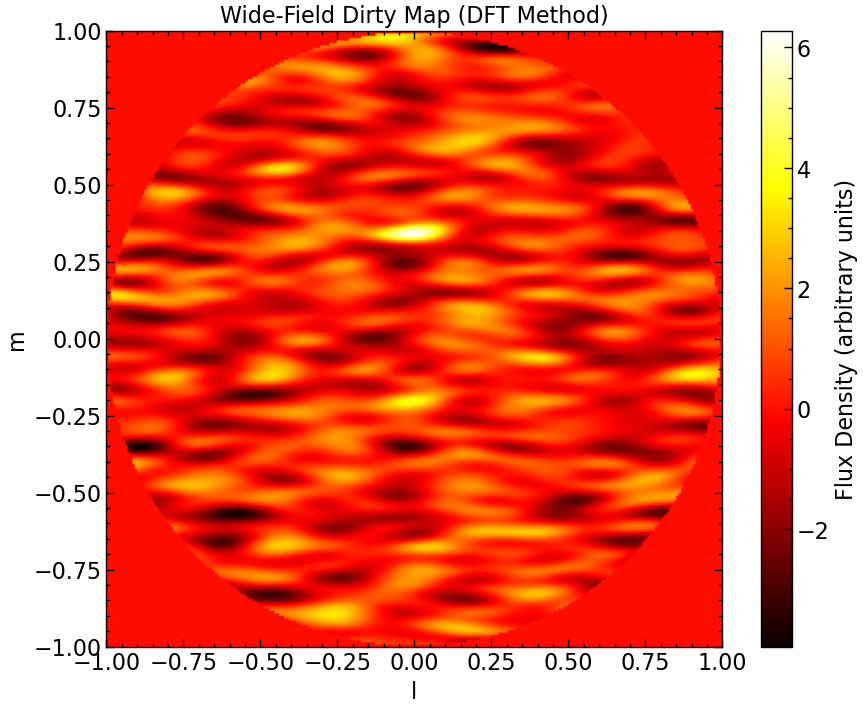

In [9]:
plt.figure(figsize=(10, 8))
plt.imshow(dirty_map, extent=[-1, 1, -1, 1], origin='lower', cmap='hot')
plt.colorbar(label='Flux Density (arbitrary units)')
plt.title('Wide-Field Dirty Map (DFT Method)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

In [10]:
from astropy.stats import sigma_clip
import scipy.ndimage as ndimage
def get_snr_map(dirty_map):
    """
    Generate an SNR map directly from the dirty image.
    Because the dirty map is a direct DFT of visibilities with independent thermal
    noise, it is *already* the optimal point source matched-filter output.
    """
    # Use sigma clipping to find the robust background RMS noise level
    # (ignoring bright sources that would otherwise inflate the standard deviation)
    clipped_map = sigma_clip(dirty_map, sigma=3.0, maxiters=5)
    sigma_image = np.std(clipped_map)
    
    # Calculate physical SNR map
    snr_map = np.abs(dirty_map / sigma_image)
    
    return snr_map

def detect_sources_from_snr(snr_map, threshold_sigma=5.0, min_distance=3):
    """
    Detect local peaks above threshold in the SNR map.
    """
    # 1. Find local maxima to avoid detecting every pixel surrounding a bright source
    local_max = ndimage.maximum_filter(snr_map, size=min_distance) == snr_map
    
    # 2. Apply sigma threshold detection
    above_threshold = snr_map > threshold_sigma
    
    # 3. Target pixels that satisfy both conditions
    detections = np.where(local_max & above_threshold)
    sources = []
    for y, x in zip(*detections):
        sources.append({
            "x_pixel": int(x),
            "y_pixel": int(y),
            "snr": float(snr_map[y, x])
        })
    # Sort sources by descending SNR so the brightest is first
    sources = sorted(sources, key=lambda s: s["snr"], reverse=True)
    return sources

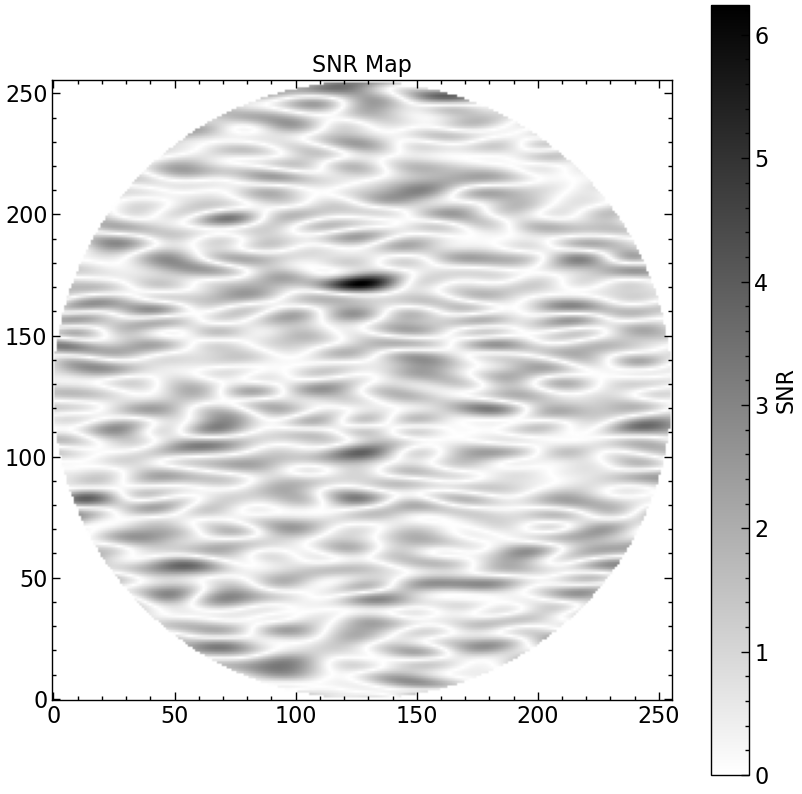

In [11]:
snr_map = get_snr_map(dirty_map)
plt.figure(figsize=(10, 10))
plt.imshow(snr_map, origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
plt.title('SNR Map')
plt.show()

In [12]:
detect_sources_from_snr(snr_map, threshold_sigma=5.0, min_distance=5)

[{'x_pixel': 126, 'y_pixel': 171, 'snr': 6.241533152741147}]

In [13]:
time_obs

<Time object: scale='utc' format='datetime' value=2026-04-01 21:12:26.915509>

In [14]:
sky_vis = generate_visibilities(antenna_mapping, 
                                frequencies, 
                                time_obs, 
                                Trec_k=25, 
                                a_eff_m2=0.2, 
                                integration_time_s = 1.0)

Generating sky model for 100 frequencies...
   Loading cached GSM model from gsm_cache/gsm_nch100_fmin390.62_fmax484.38_nside64.npy...
   Added Quiet Sun model (T_peak=8.00e+05 K, Diameter=1.2°)
Applying Gaussian primary beam...
Integrating over 24575 pixels (visible & within beam)
Beam-weighted sky temperature: [146.44935538 146.26406997 146.08038032 145.89826878 145.71771792
 145.53871056 145.36122971 145.18525854 145.01078064 144.83777963
 144.66623946 144.49614423 144.32747824 144.1602261  143.99437248
 143.82990238 143.66680086 143.5050533  143.34464519 143.18558677
 143.02794552 142.87171099 142.71686587 142.56339316 142.41127598
 142.26049788 142.11104249 141.96289389 141.81603614 141.6704537
 141.52613128 141.3830537  141.24120607 141.10057375 140.96114226
 140.82289733 140.68582496 140.54991124 140.41514256 140.28150553
 140.14898684 140.01757343 139.88725248 139.75801128 139.62983735
 139.5027183  139.37664203 139.25159657 139.12757008 139.00455098
 138.88252774 138.76148908 

Processed frequency channel 0/100
Processed frequency channel 10/100
Processed frequency channel 20/100
Processed frequency channel 30/100
Processed frequency channel 40/100
Processed frequency channel 50/100
Processed frequency channel 60/100
Processed frequency channel 70/100
Processed frequency channel 80/100
Processed frequency channel 90/100
Interpolating visibilities from 100 up to 100 channels...
Adding thermal noise with Trec=25.0 K


In [15]:
sky_vis_template = generate_visibilities(antenna_mapping, 
                                frequencies, 
                                time_obs, 
                                Trec_k=25, 
                                a_eff_m2=0.2, 
                                integration_time_s = 60.0)

Generating sky model for 100 frequencies...
   Loading cached GSM model from gsm_cache/gsm_nch100_fmin390.62_fmax484.38_nside64.npy...
   Added Quiet Sun model (T_peak=8.00e+05 K, Diameter=1.2°)
Applying Gaussian primary beam...
Integrating over 24575 pixels (visible & within beam)
Beam-weighted sky temperature: [146.44935538 146.26406997 146.08038032 145.89826878 145.71771792
 145.53871056 145.36122971 145.18525854 145.01078064 144.83777963
 144.66623946 144.49614423 144.32747824 144.1602261  143.99437248
 143.82990238 143.66680086 143.5050533  143.34464519 143.18558677
 143.02794552 142.87171099 142.71686587 142.56339316 142.41127598
 142.26049788 142.11104249 141.96289389 141.81603614 141.6704537
 141.52613128 141.3830537  141.24120607 141.10057375 140.96114226
 140.82289733 140.68582496 140.54991124 140.41514256 140.28150553
 140.14898684 140.01757343 139.88725248 139.75801128 139.62983735
 139.5027183  139.37664203 139.25159657 139.12757008 139.00455098
 138.88252774 138.76148908 

Processed frequency channel 0/100
Processed frequency channel 10/100
Processed frequency channel 20/100
Processed frequency channel 30/100
Processed frequency channel 40/100
Processed frequency channel 50/100
Processed frequency channel 60/100
Processed frequency channel 70/100
Processed frequency channel 80/100
Processed frequency channel 90/100
Interpolating visibilities from 100 up to 100 channels...
Adding thermal noise with Trec=25.0 K


In [16]:
sky_vis = sky_vis["visibilities"][...,0,0]
sky_vis_template = sky_vis_template["visibilities"][...,0,0]

In [17]:
def altaz_to_lm(alt_deg, az_deg):
    """
    Convert Altitude and Azimuth (in degrees) to l, m direction cosines.
    """
    # Step 1: Convert to radians!
    alt_rad = np.radians(alt_deg)
    az_rad = np.radians(az_deg)
    
    # Step 2: Calculate ENU direction cosines
    l = np.cos(alt_rad) * np.sin(az_rad)
    m = np.cos(alt_rad) * np.cos(az_rad)
    
    return l, m


In [33]:
alt, az = 70, 0
vis_point = generate_point_source_visibilities(
    alt,
    az,
    20,
    frequencies,
    antenna_mapping,
    time_obs=time_obs,
    integration_time_s=1.0,
    Trec_k=25,
    a_eff_m2=0.2,
)
vis_point = vis_point[..., 0,0]

   Generating visibilities for point source at Alt=70.0, Az=0.0
   Apparent flux (with beam): 16.9147 Jy
   Tsky_eff_k: [0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512 0.00122512
 0.001225

In [34]:
l_axis = np.linspace(-1, 1, 256)

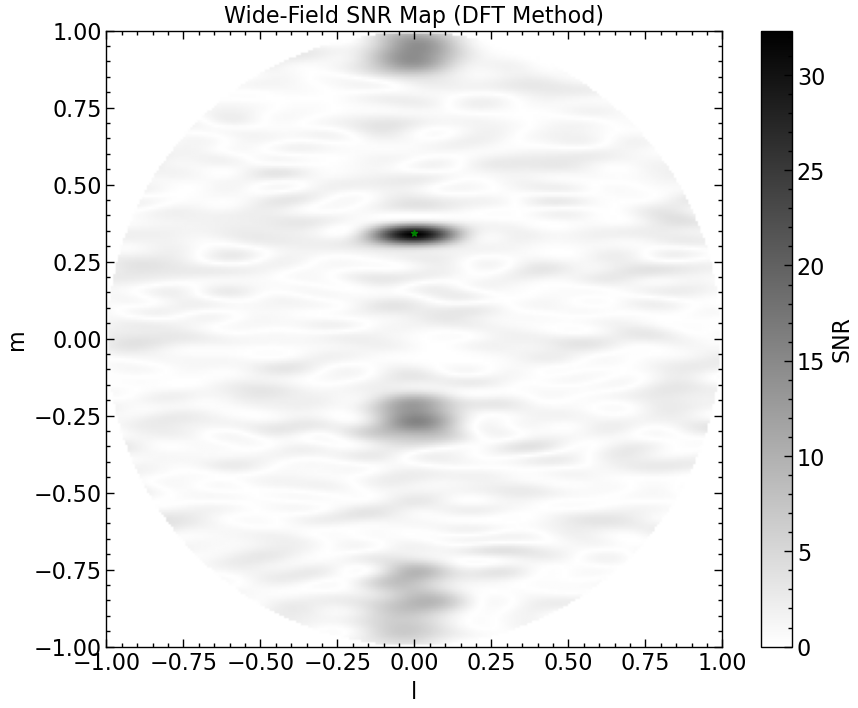

In [35]:
dirty_map_point = generate_dirty_map_gpu_chunked(vis_point, uvw_coords, res=256)
snr_map_point = get_snr_map(dirty_map_point)
plt.figure(figsize=(10, 8))
plt.imshow(snr_map_point, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20)

plt.title('Wide-Field SNR Map (DFT Method)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

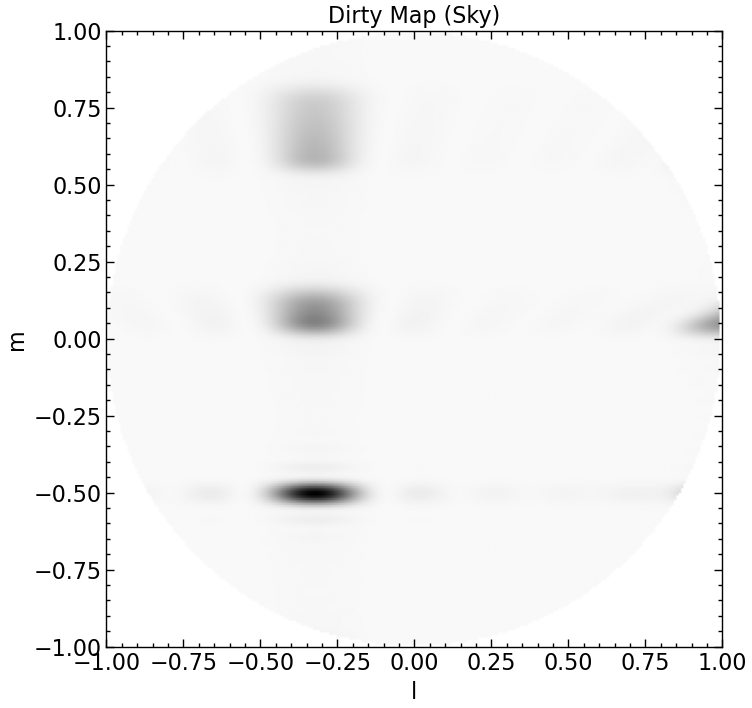

In [36]:

dirty_map_sky = generate_dirty_map_gpu_chunked(sky_vis, uvw_coords, res=256)

plt.figure(figsize=(10, 8))
plt.imshow(dirty_map_sky, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
# plt.colorbar(label='SNR')

plt.title('Dirty Map (Sky)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

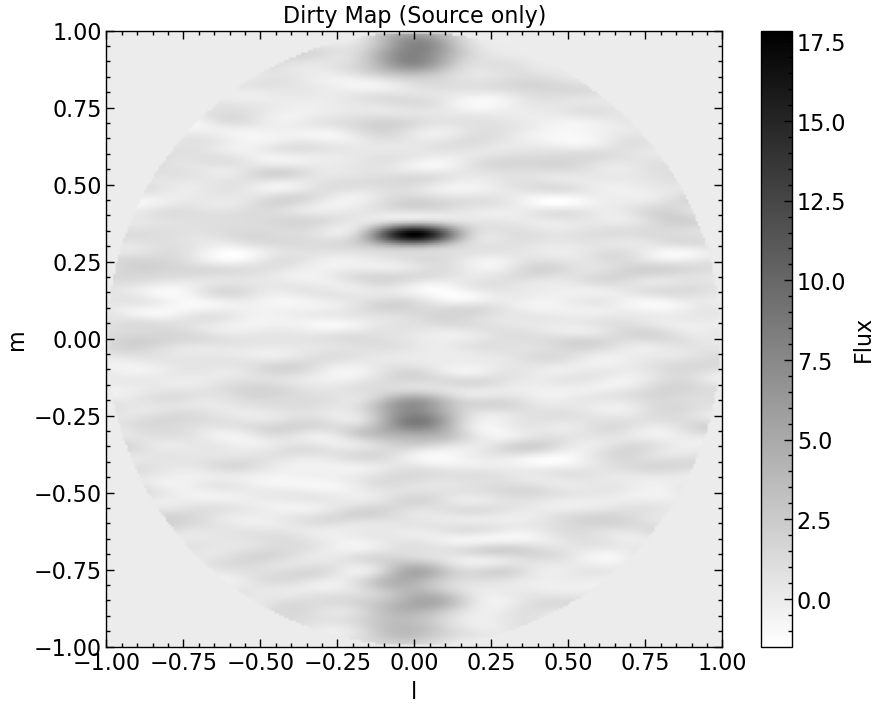

In [37]:
dirty_map_point = generate_dirty_map_gpu_chunked(vis_point, uvw_coords, res=256)
plt.figure(figsize=(10, 8))
plt.imshow(dirty_map_point, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='Flux')

plt.title('Dirty Map (Source only)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

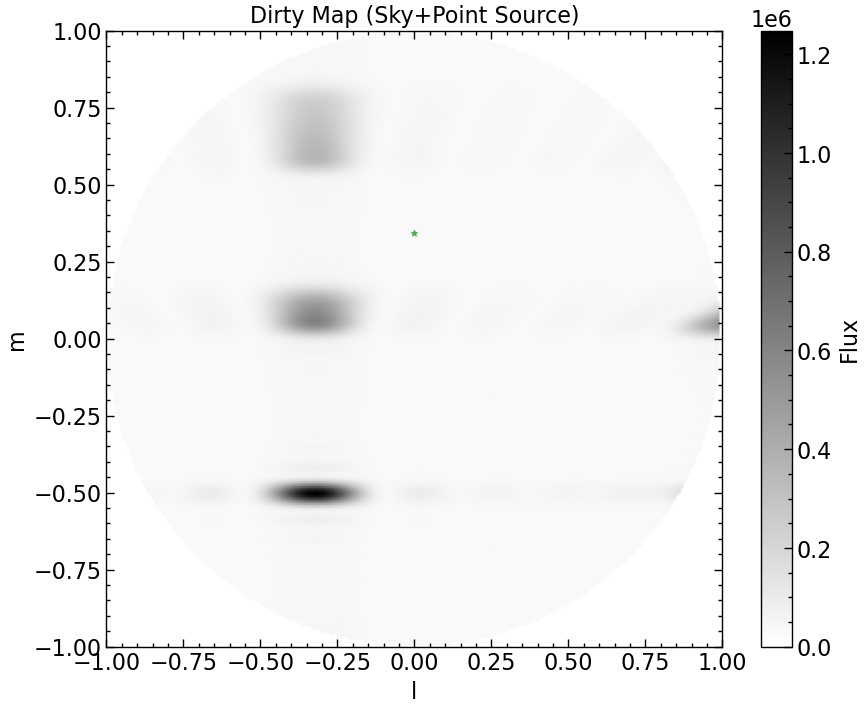

In [38]:

dirty_map_sky_src = generate_dirty_map_gpu_chunked(sky_vis+vis_point, uvw_coords, res=256)

plt.figure(figsize=(10, 8))
plt.imshow(dirty_map_sky_src, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='Flux')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20, alpha = 0.5)
plt.title('Dirty Map (Sky+Point Source)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

[{'x_pixel': 5, 'y_pixel': 158, 'snr': 5.184142324937929}]


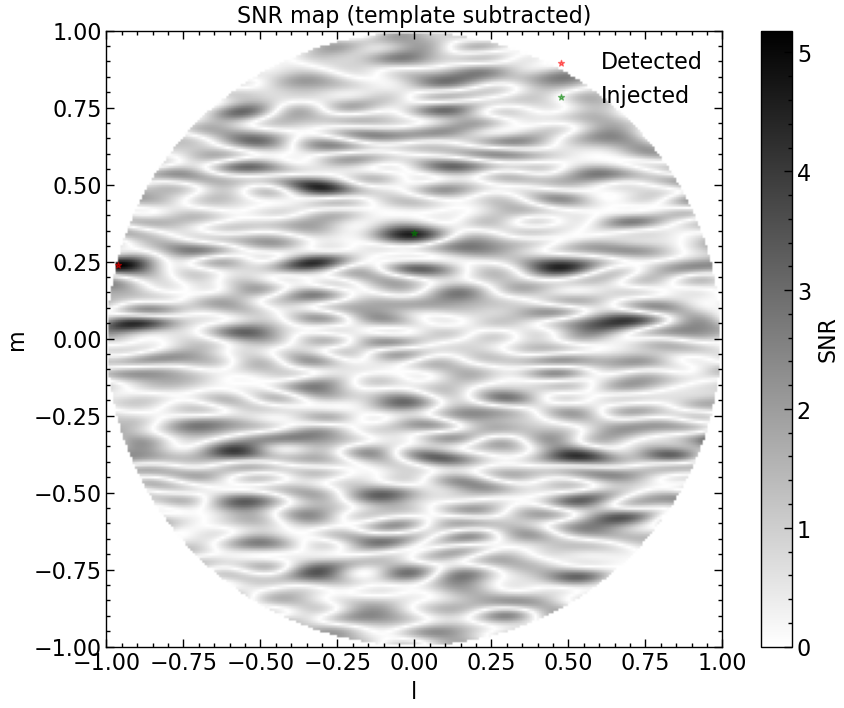

In [41]:

dirty_map_full = generate_dirty_map_gpu_chunked(sky_vis+vis_point-sky_vis_template, uvw_coords, res=256)
snr_map = get_snr_map(dirty_map_full)    
sources = detect_sources_from_snr(snr_map)
print(sources)
peak = sources[0]
x_ind, y_ind = peak['x_pixel'], peak['y_pixel']

x_loc, y_loc = l_axis[x_ind], l_axis[y_ind]
plt.figure(figsize=(10, 8))
plt.imshow(snr_map, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
plt.scatter(x_loc, y_loc, color='r', marker='*', s=20, alpha=0.5, label='Detected')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20, alpha=0.5, label='Injected')

plt.title('SNR map (template subtracted)')
plt.xlabel('l')
plt.ylabel('m')
plt.legend()
plt.show()

In [ ]:

dirty_map_full = generate_dirty_map_gpu_chunked(sky_vis+vis_point-sky_vis_template, uvw_coords, res=256)
snr_map = get_snr_map(dirty_map_full)    
sources = detect_sources_from_snr(snr_map)
print(sources)
peak = sources[0]
x_ind, y_ind = peak['x_pixel'], peak['y_pixel']

x_loc, y_loc = l_axis[x_ind], l_axis[y_ind]
plt.figure(figsize=(10, 8))
plt.imshow(snr_map, extent=[-1, 1, -1, 1], origin='lower', cmap='gray_r')
plt.colorbar(label='SNR')
plt.scatter(x_loc, y_loc, color='r', marker='*', s=20, alpha=0.5, label='Detected')
l_inj, m_inj = altaz_to_lm(alt, az)
plt.scatter(l_inj, m_inj, color='g', marker='*', s=20, alpha=0.5, label='Injected')

plt.title('SNR map (template subtracted)')
plt.xlabel('l')
plt.ylabel('m')
plt.legend()
plt.show()